#Previsão de Inadimplência de Empréstimos

## Introdução

Este conjunto de dados reúne informações de clientes e de seus empréstimos (dados demográficos, detalhes contratuais e histórico de crédito). Ele é adequado para análises estatísticas e tarefas de aprendizado de máquina voltadas a prever o risco de inadimplência.

Segundo Serasa:

>  O Brasil registrou 78,2 milhões de pessoas inadimplentes em julho de 2025.

##  Objetivo do Projeto

Desenvolver e avaliar modelos de classificação binária para estimar a probabilidade de um cliente entrar em inadimplência no empréstimo ativo.

- **Variável-alvo** sugerida: `current_loan_status`

Classes: `INADIMPLÊNCIA vs SEM INADIMPLÊNCIA``

Sugestão de codificação: `1 = INADIMPLÊNCIA, 0 = SEM INADIMPLÊNCIA`



###Dicionário de Dados

Este conjunto de dados contém informações sobre empréstimos de clientes, incluindo dados demográficos de clientes, detalhes de empréstimos e status de inadimplência. O conjunto de dados pode ser usado para diversas análises de dados e tarefas de aprendizado de máquina, como prever o risco de inadimplência de empréstimos. O conjunto de dados consiste nas seguintes colunas:

1. **customer_id**: identificador exclusivo para cada cliente

2. **customer_age**: Idade do cliente

3. **customer_income**: Renda anual do cliente

4. **home_ownership**: status de propriedade da casa (por exemplo, ALUGUEL, PRÓPRIO,
HIPOTECA)

5. **Employment_duration**: Duração do emprego em meses

6. **loan_intent**: Finalidade do empréstimo (por exemplo, PESSOAL, EDUCAÇÃO,
MÉDICO, EMPREENDIMENTO)

7. **loan_grade**: Nota atribuída ao empréstimo

8. **loan_amnt**: valor do empréstimo solicitado

9. **loan_int_rate**: Taxa de juros do empréstimo

10. **term_years**: Prazo do empréstimo em anos

11. **historic_default**: Indica se o cliente possui histórico de inadimplência (S/N)

12. **cred_hist_length**: Comprimento do histórico de crédito do cliente em anos

13. **Current_loan_status**: Status atual do empréstimo  (INADIMPLÊNCIA, SEM INADIMPLÊNCIA)

##Importação das bibliotecas


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

Explorando o DataFrame

In [2]:
#Carregando o DataFrame
df_current = pd.read_csv('LoanDataset - LoansDatasest.csv')
df_current.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


### ✅ Informações gerais:
- **Formato:** `pandas.DataFrame`
- **Número de entradas:** 32.586  
- **Número de colunas:** 13
- **Tipos de dados:**
  - `object`: 7 colunas → `customer_income`, `home_ownership`, `loan_intent`, `loan_grade`, `loan_amnt`, `historical_default`, `Current_loan_status`
  - `int64`: 3 colunas → `customer_age`, `term_years`, `cred_hist_length`
  - `float64`: 3 colunas → `customer_id`, `employment_duration`, `loan_int_rate`
- **Dados ausentes (total):** 24.756 células (≈ **5,84%** de 423.618)
  - `historical_default`: 20.737 (63,64%)
  - `loan_int_rate`: 3.116 (9,56%)
  - `employment_duration`: 895 (2,75%)
  - `Current_loan_status`: 4 (0,01%)
  - `customer_id`: 3 (0,01%)
  - `loan_amnt`: 1 (≈0,00%)

### 📌 Principais grupos de variáveis
- **Identificação:** `customer_id`
- **Demográficas / renda e moradia:** `customer_age`, `customer_income`, `home_ownership`, `employment_duration`
- **Atributos do empréstimo:** `loan_intent`, `loan_grade`, `loan_amnt`, `loan_int_rate`, `term_years`
- **Histórico de crédito:** `historical_default`, `cred_hist_length`
- **Alvo (status atual):** `Current_loan_status`

A variável **`Current_loan_status`** é a **variável-alvo**, onde recomenda-se codificar:
- `INADIMPLÊNCIA` → `1`
- `SEM INADIMPLÊNCIA` → `0`

### 🧪 Considerações
- **Conversões recomendadas:** `customer_income` e `loan_amnt` estão como `object` mas são numéricas → limpar/remover símbolos e converter para `float`.  
- **Tratamento de nulos:** imputar `historical_default`, `loan_int_rate` e `employment_duration` (estratégia a depender da distribuição/negócio).  
- **Codificação categórica:** One-Hot/WOE para `home_ownership`, `loan_intent`, `loan_grade`.  
- **Validação:** checar possível **desbalanceamento** em `Current_loan_status` antes de definir métricas e limiar de decisão.

In [3]:
#Visualizando Informações do DataSet
df_current.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  object 
 3   home_ownership       32586 non-null  object 
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  object 
 6   loan_grade           32586 non-null  object 
 7   loan_amnt            32585 non-null  object 
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  object 
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 3.2+ MB


## Valores Ausentes

### ✅ Resumo
- **Total de linhas:** 32586
- **Total de colunas:** 13
- **Células ausentes (total):** 4019 de 423618 (≈ **0.95%**)

### 🔎 Insights rápidos
- Principais fontes de nulos: **`loan_int_rate`** (9,56%) e **`employment_duration`** (2,75%).
- Nulos residuais: **`Current_loan_status`** (4), **`customer_id`** (3) e **`loan_amnt`** (1).
- Demais colunas sem valores ausentes.



In [4]:
#Contando os Valores Vazios
df_current.isnull().sum()

,0
customer_id,3
customer_age,0
customer_income,0
home_ownership,0
employment_duration,895
loan_intent,0
loan_grade,0
loan_amnt,1
loan_int_rate,3116
term_years,0


Dropando a coluna *customer_id* visto que essa feature não ira colaborar para construção da rede neural

In [5]:
#Dropando a Coluna: customer_id
df_current.drop(columns=['customer_id'], axis = 1, inplace=True)

## Estatística Descritiva

### Escalas muito diferentes entre variáveis
- **customer_income** (até **6 milhões**) e **loan_amnt** (até **3,5 milhões**) apresentam **alta amplitude** e **assimetria**, sugerindo **padronização** e possivelmente **winsorização/tratamento de outliers**.
- **loan_int_rate** está numa escala bem menor (**5,42–23,22**), reforçando a necessidade de **escalonamento** ao combinar variáveis em modelos baseados em distância.

### Outliers e qualidade de dados
- **customer_age** tem **máximo 144**, valor potencialmente **inválido** (erro de digitação/integração). Recomenda-se checagem e **capping**.
- **employment_duration** vai de **0 a 123** meses; zeros podem indicar **desemprego** ou **dados faltantes codificados**.

### Padrões do produto
- **term_years** concentra-se nos quantis em **3, 4 e 7** anos, coerente com prazos comuns (**3, 5, 7, 10**).
- **cred_hist_length** (mediana **4**, p75 **8**) indica histórico de crédito geralmente **curto a moderado**.

### Dispersão
- A **dispersão (std)** varia bastante entre variáveis, reforçando a importância de **normalização/padronização** antes da modelagem.


In [6]:
#Visualizando Estatísticas Descritivas
df_current.describe()

,customer_age,employment_duration,loan_int_rate,term_years,cred_hist_length
count,32586.000000,31691.000000,29470.000000,32586.000000,32586.000000
mean,27.732769,4.790161,11.011553,4.761738,5.804026
std,6.360528,4.142746,3.240440,2.471107,4.055078
min,3.000000,0.000000,5.420000,1.000000,2.000000
25%,23.000000,2.000000,7.900000,3.000000,3.000000
50%,26.000000,4.000000,10.990000,4.000000,4.000000
75%,30.000000,7.000000,13.470000,7.000000,8.000000
max,144.000000,123.000000,23.220000,10.000000,30.000000


## Limpeza de dados e tratamento dos dados

1) Foi possível analisar que na coluna *Historical default* que tinha 20.733 valores ausentes, é importante ressaltar que essa coluna é responsável por registrar se a pessoas tem ou não tem histórico de inadiplência.Optei por trocar esses valores NaN's por *missing* ou seja ausente, visto que pode ter sido a primeira vez que a pessoa foi recorrer ao empréstimo, isso é apenas uma suposição essa ideia

2) Foi necessário tratar a coluna *Loan amnt* visto que ela está no tipo *object* mas possui valores númericos, isso acontece pois os valores númericos recebem *£* que é um caractere string e substituimos por espaço vazio, na mesma coluna os valores númericos recebem a virgula entre os números, a virgula é considerado uma string para isso substituimos por um espaço vazio

3) Na coluna *Customer Income* acontece a mesma ocasião da coluna comentada anteriormente apenas fazer um replace de um vírgula por um espaço vazio.

4) Foi necessário esse tratamento desses dados, pois pela minha consulta esses dados não possuem clareza e nem certeza que esse valores podem existir


In [7]:
#Filtrando Valores Vazios
df_current['historical_default'] = df_current['historical_default'].fillna("missing")

In [8]:
#Transformando em coluna numérica (Float)
df_current['loan_amnt'] = df_current['loan_amnt'].str.replace("£","").str.replace(",","").astype(float)

In [9]:
#Transformando em Coluna Inteira (Int)
df_current['customer_income'] = df_current['customer_income'].str.replace(",","").astype(int)

In [10]:
#Removendo Valores Irreias
df_current = df_current[(df_current['customer_age'] > 18) & (df_current['customer_age'] <= 100) ]   #Idade > 18 e <= 100
df_current = df_current[df_current['employment_duration'] <=12] #Meses > 12
df_current = df_current[df_current['cred_hist_length'] !=30] #comprimento meses > 12

In [11]:
df_current.describe()

,customer_age,customer_income,employment_duration,loan_amnt,loan_int_rate,term_years,cred_hist_length
count,30048.000000,3.004800e+04,30048.000000,3.004700e+04,27159.000000,30048.000000,30048.000000
mean,27.349042,6.523953e+04,4.202776,9.763101e+03,11.058639,4.773462,5.579573
std,5.965385,4.981647e+04,3.169686,2.258904e+04,3.221705,2.454979,3.906092
min,20.000000,4.000000e+03,0.000000,5.000000e+02,5.420000,1.000000,2.000000
25%,23.000000,3.900000e+04,2.000000,5.000000e+03,7.900000,3.000000,3.000000
50%,26.000000,5.500000e+04,4.000000,8.000000e+03,11.030000,4.000000,4.000000
75%,29.000000,7.800000e+04,6.000000,1.210000e+04,13.480000,7.000000,8.000000
max,94.000000,2.039784e+06,12.000000,3.500000e+06,23.220000,10.000000,29.000000


Distribuição da Variável Alvo

| Classe         |   Contagem |          % |
| -------------- | ---------: | ---------: |
| **NO DEFAULT** |     22.643 | **79,07%** |
| **DEFAULT**    |      5.995 |     20,93% |
| **Total**      | **28.638** |       100% |

> Essa Observação será crucial para o treinamento do model, considerando que as divisão dos dados podem ficar desbalanceadas

In [12]:
df_current['Current_loan_status'].value_counts()

,count
Current_loan_status,
NO DEFAULT,23690
DEFAULT,6354


## Análise de Outilers

Durante a análise descritivas dos dados, percebe-se três grandes observações. Discrepância entre Q3 e Q4 dos Dados

1. `customer_income`

2. `loan_amnt`

3. `cred_hist_length`

Para isso, foi necessário criar uma função para visualizar essas outilers, graficamente e estatiscamente.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualizar_outliers(df, nome_coluna, fator_iqr=1.5):
    """
    Visualiza outliers em uma coluna numérica usando um boxplot, e então os trata
    usando o método especificado (capping ou mediana) e exibe um novo boxplot.
    Os boxplots serão exibidos no formato vertical.

    Args:
        df (pd.DataFrame): O DataFrame que contém a coluna a ser analisada.
        nome_coluna (str): O nome da coluna numérica para tratamento de outliers.
        fator_iqr (float): O fator multiplicador para o IQR (padrão é 1.5 para outliers comuns).

    Returns:
        Gráficos Boxplots para Visualiação de Outilers e Tratamento
    """
    # Cria uma cópia explícita do DataFrame para evitar modificações no original
    df_copia = df.copy()

    if nome_coluna not in df_copia.columns:
        print(f"Erro: A coluna '{nome_coluna}' não existe no DataFrame.")
        return df

    if not pd.api.types.is_numeric_dtype(df_copia[nome_coluna]):
        print(f"Erro: A coluna '{nome_coluna}' não é numérica. O tratamento de outliers é para dados numéricos.")
        return df

    # --- 1. Visualizar Boxplot com Outliers (Vertical) ---
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df_copia[nome_coluna])
    plt.title(f'Boxplot da Coluna "{nome_coluna}" (Com Outliers)')
    plt.ylabel(nome_coluna)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # --- 2. Calcular Limites do IQR ---
    Q1 = df_copia[nome_coluna].quantile(0.25)
    Q3 = df_copia[nome_coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - fator_iqr * IQR
    limite_superior = Q3 + fator_iqr * IQR

    print(f"\n--- Detalhes para '{nome_coluna}' ---")
    print(f"Q1 (25º Percentil): {Q1:.2f}")
    print(f"Q3 (75º Percentil): {Q3:.2f}")
    print(f"IQR (Intervalo Interquartil): {IQR:.2f}")
    print(f"Limite Inferior para Outliers: {limite_inferior:.2f}")
    print(f"Limite Superior para Outliers: {limite_superior:.2f}")

    # Identificar outliers
    outlier_cond = (df_copia[nome_coluna] < limite_inferior) | (df_copia[nome_coluna] > limite_superior)
    num_outliers = df_copia[outlier_cond].shape[0]
    porcentagem_outliers = (num_outliers / len(df_copia)) * 100

    print(f"Número de Outliers Identificados: {num_outliers}")
    print(f"Porcentagem de Outliers: {porcentagem_outliers:.2f}%")

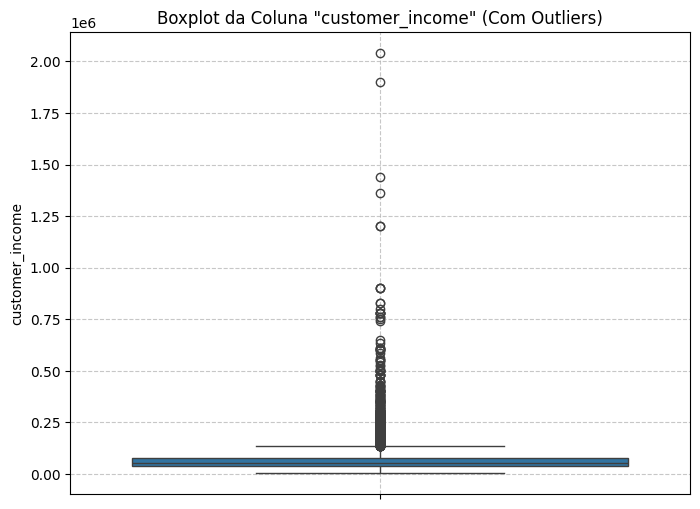


--- Detalhes para 'customer_income' ---
Q1 (25º Percentil): 39000.00
Q3 (75º Percentil): 78000.00
IQR (Intervalo Interquartil): 39000.00
Limite Inferior para Outliers: -19500.00
Limite Superior para Outliers: 136500.00
Número de Outliers Identificados: 1446
Porcentagem de Outliers: 4.81%


In [14]:
visualizar_outliers(df_current, 'customer_income')

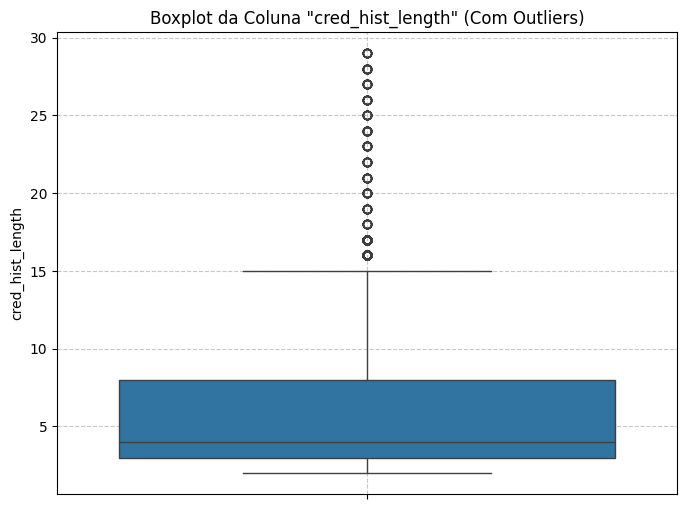


--- Detalhes para 'cred_hist_length' ---
Q1 (25º Percentil): 3.00
Q3 (75º Percentil): 8.00
IQR (Intervalo Interquartil): 5.00
Limite Inferior para Outliers: -4.50
Limite Superior para Outliers: 15.50
Número de Outliers Identificados: 941
Porcentagem de Outliers: 3.13%


In [15]:
visualizar_outliers(df_current, 'cred_hist_length')

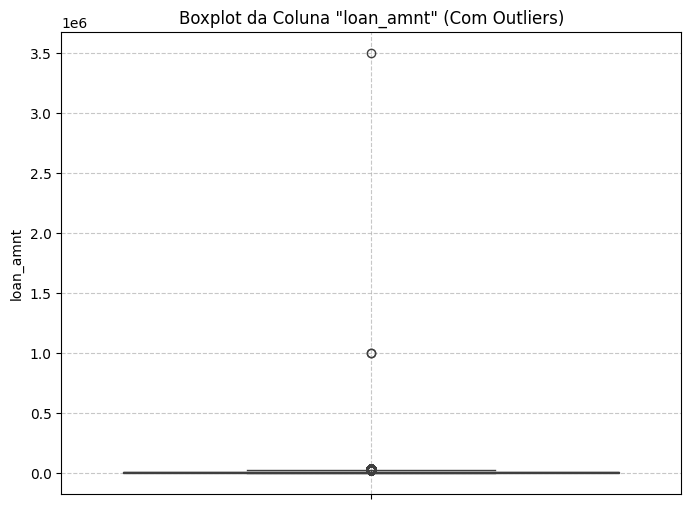


--- Detalhes para 'loan_amnt' ---
Q1 (25º Percentil): 5000.00
Q3 (75º Percentil): 12100.00
IQR (Intervalo Interquartil): 7100.00
Limite Inferior para Outliers: -5650.00
Limite Superior para Outliers: 22750.00
Número de Outliers Identificados: 1568
Porcentagem de Outliers: 5.22%


In [16]:
visualizar_outliers(df_current, 'loan_amnt')

### Tratamento de Outilers



In [17]:
def capear_iqr(series, fator_iqr=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    li, ls = Q1 - fator_iqr*IQR, Q3 + fator_iqr*IQR
    return series.clip(lower=li, upper=ls)

In [18]:
df_current['customer_income'] = capear_iqr(df_current['customer_income'])
df_current['loan_amnt'] = capear_iqr(df_current['loan_amnt'])
df_current['cred_hist_length'] = capear_iqr(df_current['cred_hist_length'])

In [19]:
df_current.describe()

,customer_age,customer_income,employment_duration,loan_amnt,loan_int_rate,term_years,cred_hist_length
count,30048.000000,30048.000000,30048.000000,30047.000000,27159.000000,30048.000000,30048.00000
mean,27.349042,61964.178415,4.202776,9391.504976,11.058639,4.773462,5.49782
std,5.965385,30932.127031,3.169686,5756.784145,3.221705,2.454979,3.61242
min,20.000000,4000.000000,0.000000,500.000000,5.420000,1.000000,2.00000
25%,23.000000,39000.000000,2.000000,5000.000000,7.900000,3.000000,3.00000
50%,26.000000,55000.000000,4.000000,8000.000000,11.030000,4.000000,4.00000
75%,29.000000,78000.000000,6.000000,12100.000000,13.480000,7.000000,8.00000
max,94.000000,136500.000000,12.000000,22750.000000,23.220000,10.000000,15.50000


#Análise de Dados

Esta etapa organiza as colunas do DataFrame em variáveis numéricas contínuas e variáveis categóricas para facilitar a EDA (Análise Exploratória de Dados) e o pré-processamento.

🎯 Objetivo

Padronizar o fluxo de EDA: números e categorias pedem análises/visualizações diferentes.

Preparar o pré-processamento: escalonar/normalizar variáveis contínuas e codificar variáveis categóricas.

In [20]:
categorical_val = []
continuos_val =[]
for column in df_current.columns:
  if df_current[column].dtype == 'float64' or df_current[column].dtype == 'int64':
    continuos_val.append(column)
  else:
    categorical_val.append(column)

1.  Clientes RENT têm maior taxa de DEFAULT do que MORTGAGE e OWN?

  **Insights do gráfico**:

  - **MORTGAGE** domina em volume e aparenta menor fração de DEFAULT.

  - **RENT** mostra proporção visualmente maior de DEFAULT.

  - **OWN** intermediário; OTHER é raro.

---

2.  A finalidade do empréstimo se relaciona ao risco? Quais intents têm maior taxa de DEFAULT?

  **Insights do gráfico**:

  - **EDUCATION e DEBTCONSOLIDATION** concentram volume.

  - **VENTURE e PERSONAL** sugerem fração maior de DEFAULT.

---
3.  Existe relação monotônica entre nota (A→E) e inadimplência? Em que faixa a taxa acelera?

  **Insights do gráfico**:

  - **A** tem alto volume e menor parcela de **DEFAULT**.

  - **C/D/E** exibem mais DEFAULT proporcionalmente (mesmo com menos casos).

---
4. Ter histórico prévio (Y) aumenta a chance de DEFAULT? O grupo “missing” tem comportamento atípico?

**Insights do gráfico**:

  - “missing” é massivo e majoritariamente **NO DEFAULT** (pode indicar viés de coleta).

  - Diferença entre **Y** e **N** não é óbvia visualmente.

---
5.  O desbalanceamento (~79% NO DEFAULT vs ~21% DEFAULT) exige class weights/reamostragem e muda a métrica ideal?

  **Insights do gráfico**:

  - Forte desbalanceamento de classes.

  - **Ação/validação**: split estratificado, class weights ou SMOTE/Under; priorizar ROC-AUC, PR-AUC, Recall/F1 da classe DEFAULT.



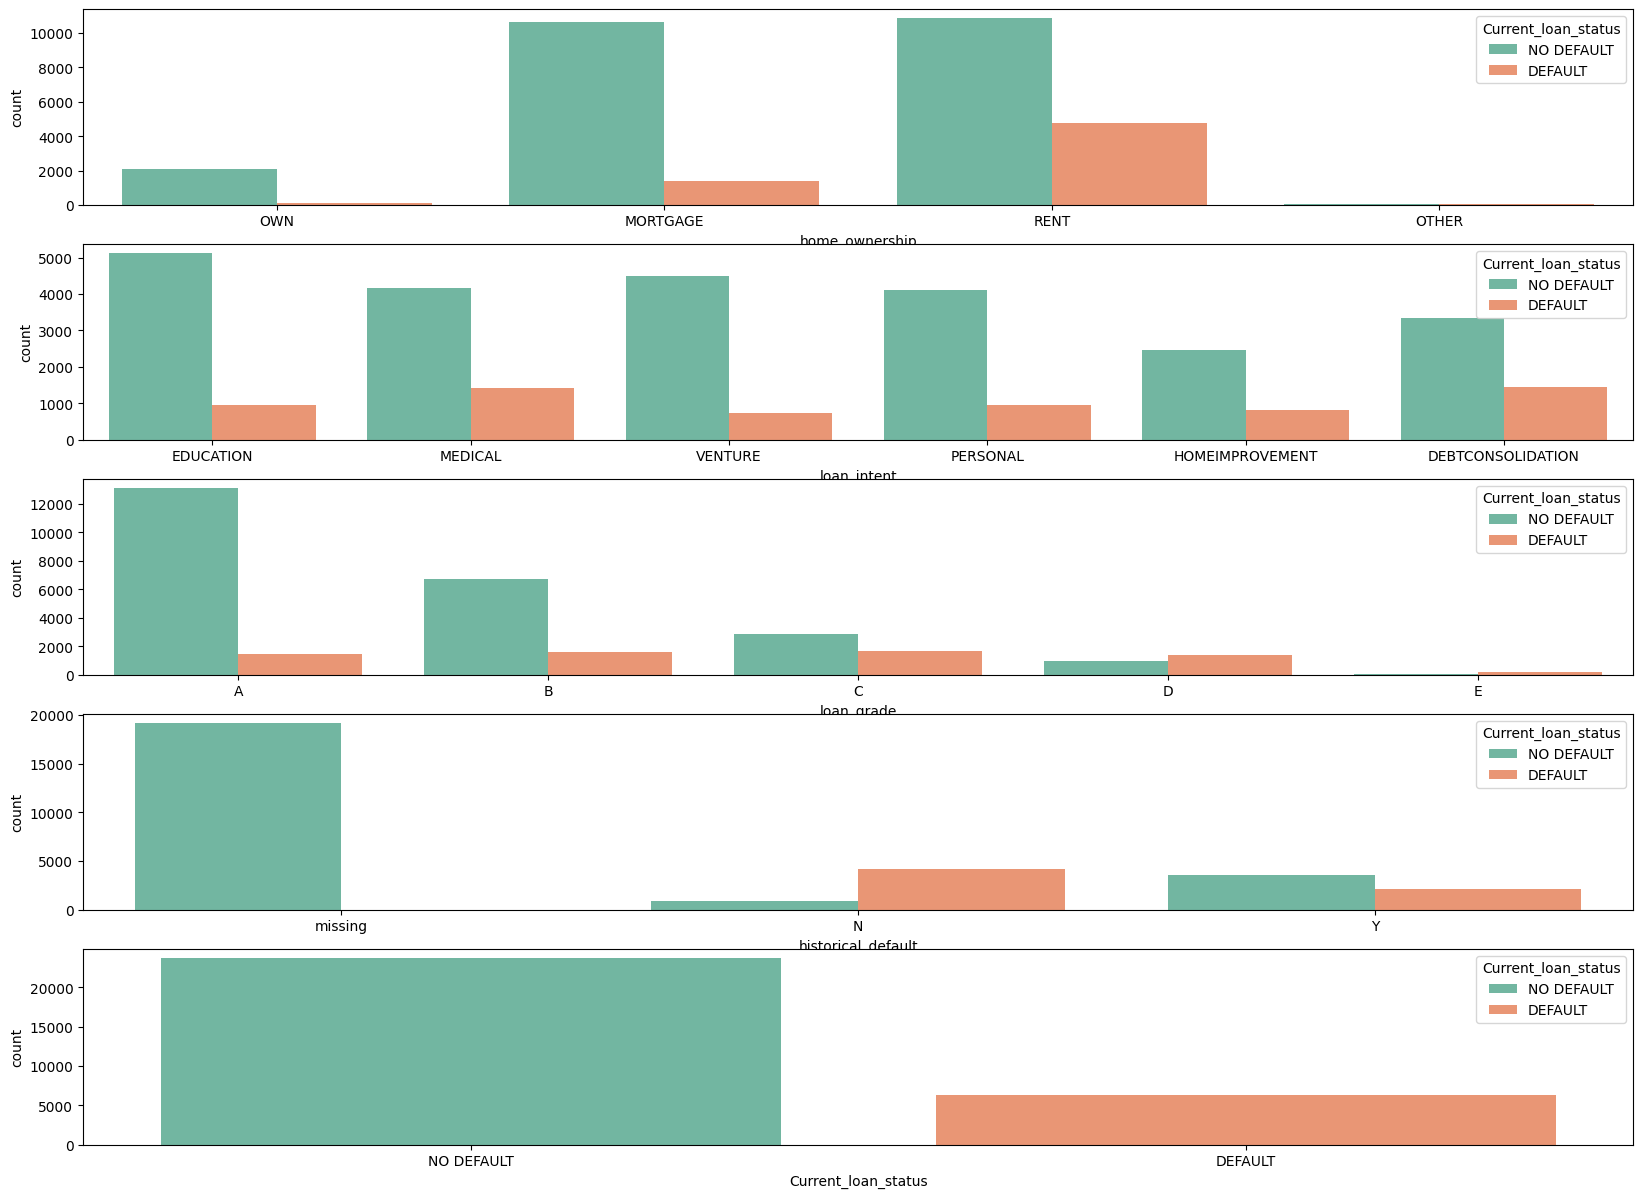

In [21]:
#Ajustando a Configuração do Gráfico
plt.figure(figsize=(20, 30))

#Plotando os Gráficos
for i, column in enumerate(categorical_val, 1):
    plt.subplot(10, 1, i)
    sns.countplot(x=column, hue='Current_loan_status', data=df_current, palette ='Set2')
    plt.xlabel(column)

1. **Clientes mais jovens apresentam maior taxa de DEFAULT?**  

**Insights do gráfico**:  
- A curva de **DEFAULT** aparece mais concentrada na faixa **20–28 anos**.  
- **NO DEFAULT** se distribui em idades mais amplas.  
- Há outliers em idades muito altas (até 100), que devem ser tratados.  

---

2. **Rendas mais baixas concentram maior probabilidade de DEFAULT?**  

**Insights do gráfico**:  
- Forte **assimetria**: a maior parte dos clientes está abaixo de **80k de renda**.  
- A densidade de **DEFAULT** é maior nas faixas de **baixa renda**, enquanto **NO DEFAULT** se estende a valores mais altos.  
- Recomenda-se **transformação logarítmica** (`log1p`) e análise de outliers.  

---

3. **Menor tempo de emprego aumenta a chance de DEFAULT?**  

**Insights do gráfico**:  
- Clientes com **0–3 anos de emprego** têm densidade maior de **DEFAULT**.  
- **NO DEFAULT** se distribui mais ao longo dos anos de experiência.  
- Valor **0** pode representar tanto “sem emprego” quanto **dados faltantes codificados**.  

---

4. **Valores maiores de empréstimo aumentam a chance de DEFAULT?**  

**Insights do gráfico**:  
- A distribuição é bastante **assimétrica**, com concentração de empréstimos até **15k**.  
- **DEFAULT** tem maior presença em faixas **mais baixas**, mas com sobreposição.  
- Cauda longa até **250k**, exigindo **capping** ou transformação.  

---

5. **Taxas de juros mais altas implicam maior probabilidade de DEFAULT?**  

**Insights do gráfico**:  
- A curva de **DEFAULT** é mais densa acima de **13% de taxa de juros**.  
- **NO DEFAULT** tem maior concentração entre **7–12%**.  
- `loan_int_rate` parece ser **variável relevante para risco**.  


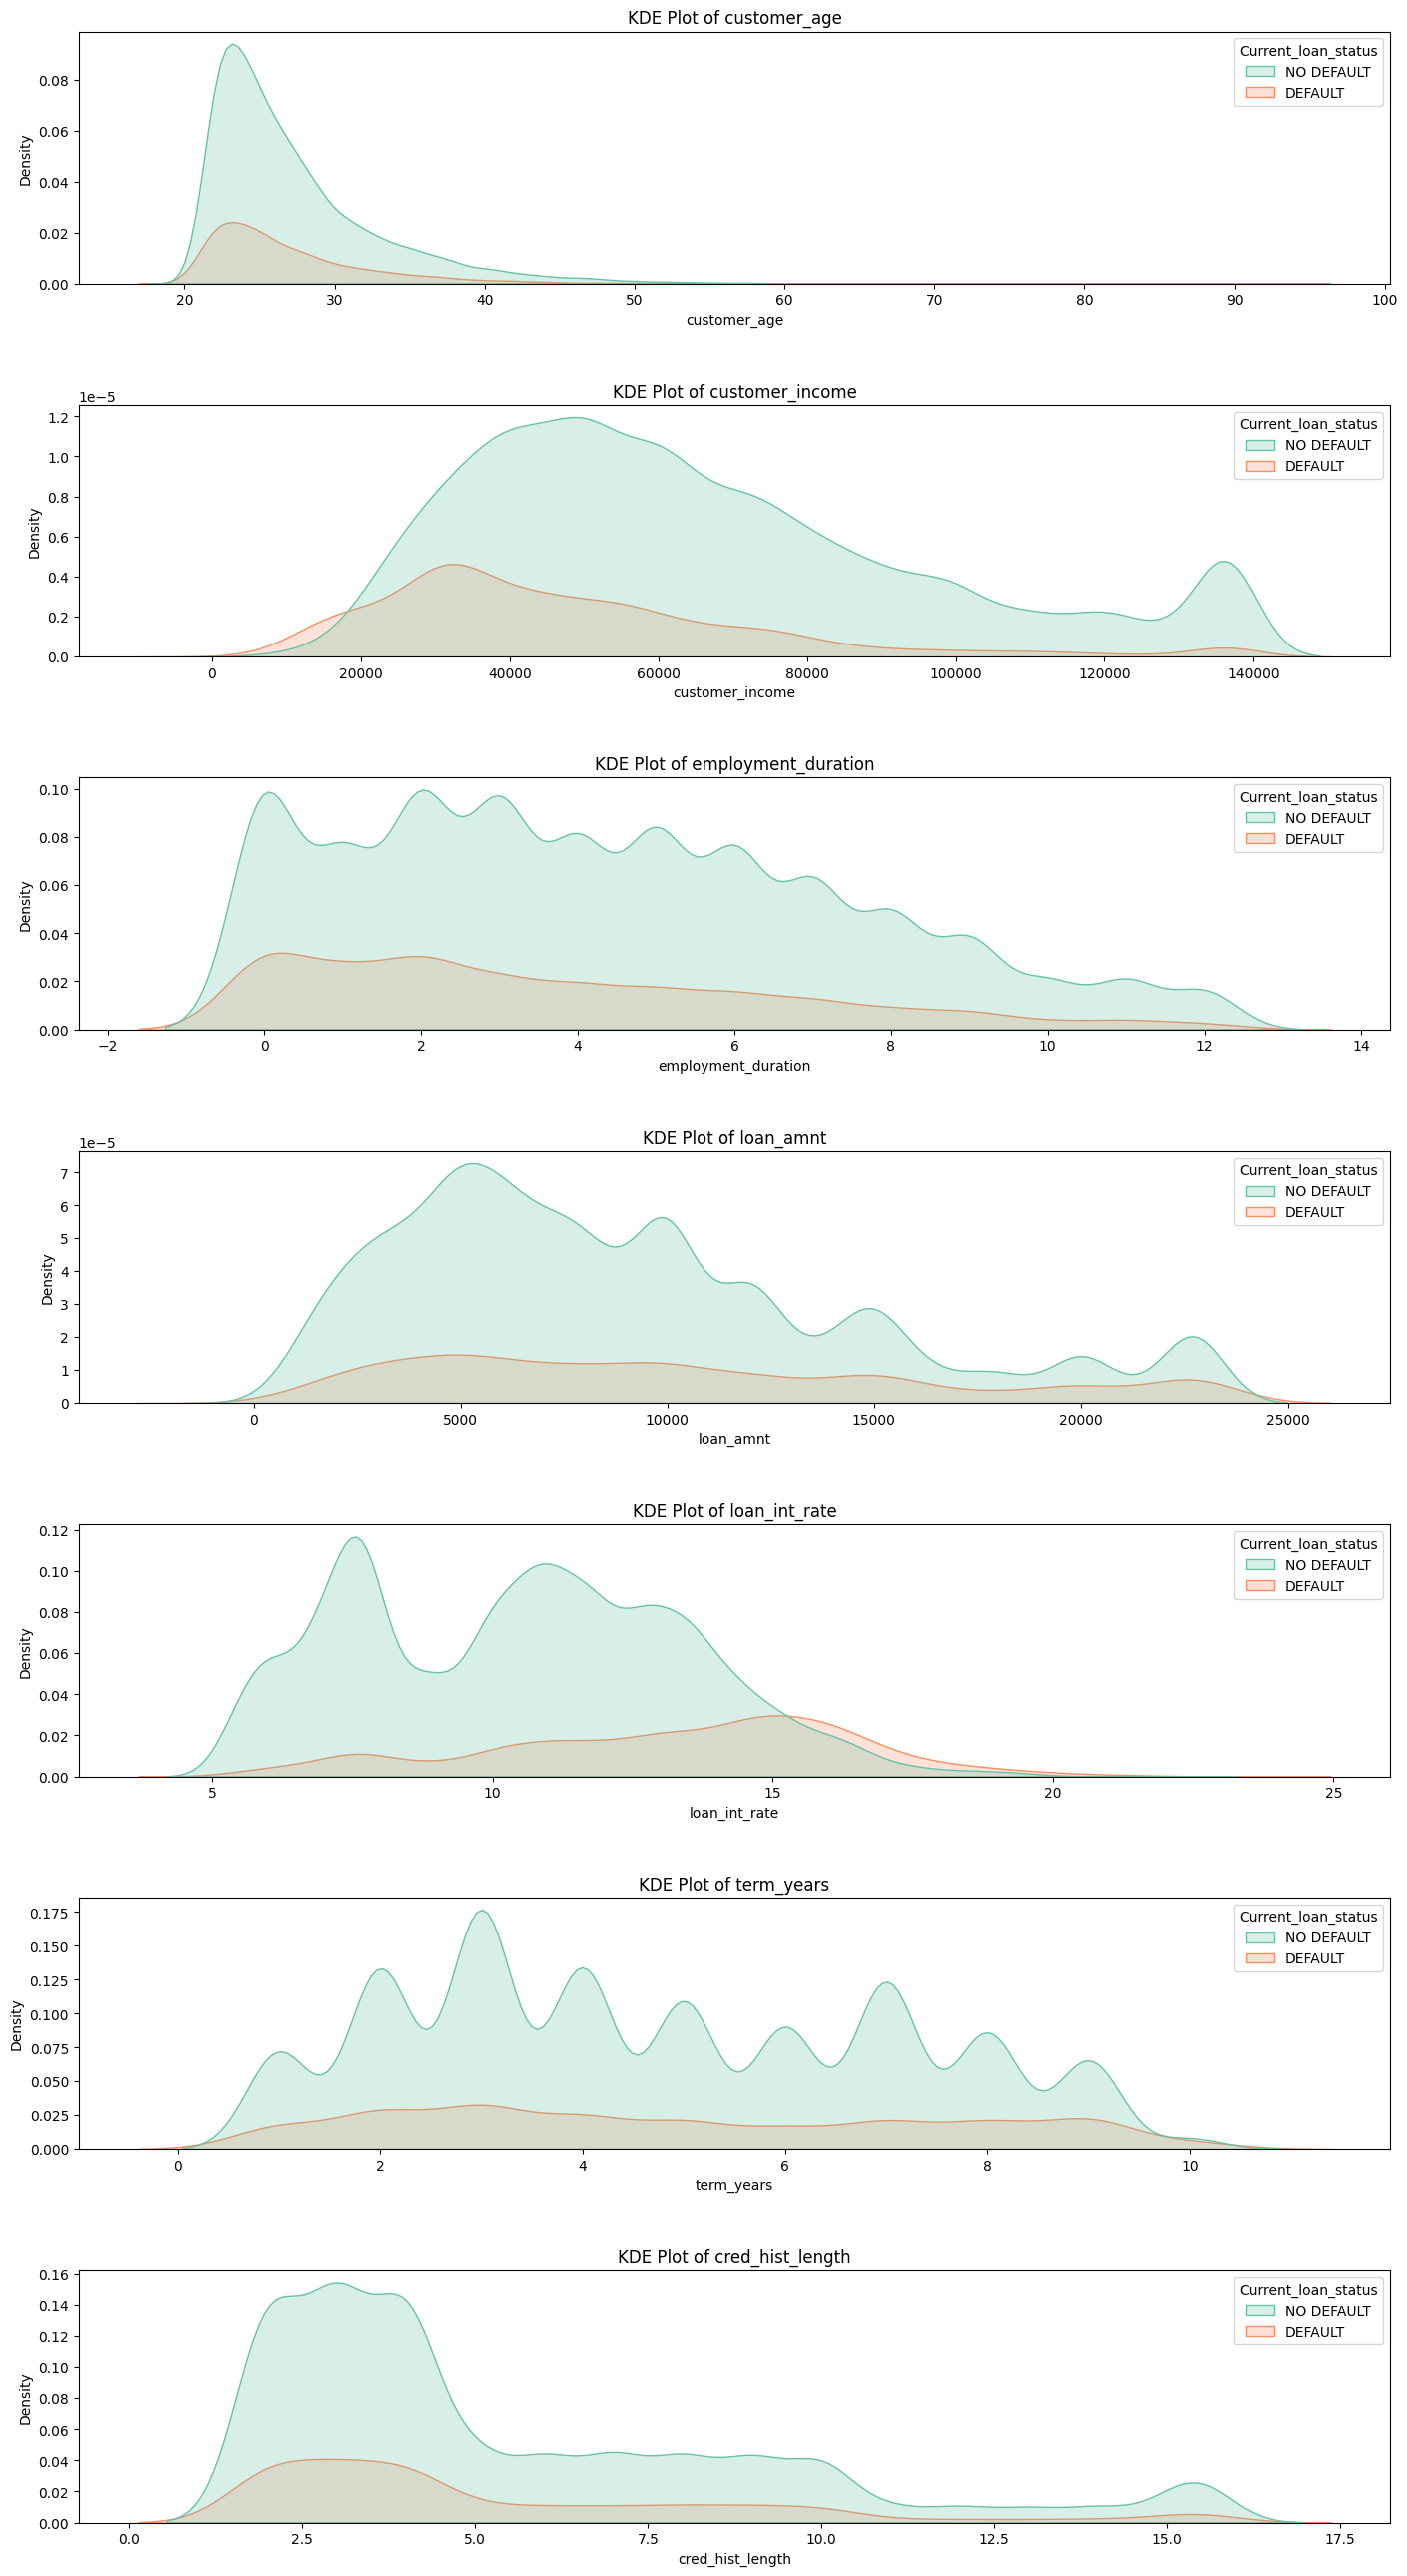

In [22]:
plt.figure(figsize=(15, 30))
for i, column in enumerate(continuos_val, 1):
    plt.subplot(8, 1, i)
    sns.kdeplot(x=column, hue="Current_loan_status", data=df_current, palette="Set2", fill =True)
    plt.title(f"KDE Plot of {column}") # Changed title to reflect plot type
    plt.tight_layout(pad=4.0)
plt.show()


## Análise de correlação dos dados

### 🔎 Principais Observações

1. **`customer_age` × `cred_hist_length`**  
   - Correlação **forte e positiva (0.86)**.  
   - Faz sentido: clientes mais velhos tendem a ter **histórico de crédito mais longo**.  
   - **Insight:** essas variáveis carregam informação similar → avaliar **redundância** ou criar **feature derivada** (ex.: `age - cred_hist_length`).  

2. **Correlação moderada (0.10–0.20)**  
   - `customer_age` × `customer_income` (0.18).  
   - `employment_duration` × `cred_hist_length` (0.15).  
   - `term_years` × `customer_age` (0.13).  
   - **Insight:** associações lógicas, mas não tão fortes → podem contribuir de forma **complementar** no modelo.  

3. **Correlação fraca (<0.10)**  
   - `loan_amnt`, `loan_int_rate`, `term_years` mostram **baixa relação** com as demais variáveis.  
   - **Insight:** indicam que podem adicionar **sinais independentes** ao modelo, sem multicolinearidade significativa.  

4. **Correlação negativa fraca**  
   - `loan_int_rate` × `employment_duration` (≈ -0.06).  
   - Pode indicar que **clientes mais estáveis** no emprego têm acesso a **juros mais baixos**.  

---

### 📌 Considerações para Modelagem
- **Multicolinearidade:**  
  - `customer_age` e `cred_hist_length` devem ser avaliados. Em regressões lineares, pode ser necessário **remover uma** ou usar técnicas de **regularização** (Ridge/Lasso).  
  - Em **árvores/GBMs**, o impacto é menor, mas ainda pode dificultar interpretabilidade.
  
- **Feature Engineering:**  
  - Criar novas variáveis a partir das relações detectadas (ex.: razão `loan_amnt / customer_income`, diferença `customer_age - cred_hist_length`).  

- **Seleção de Variáveis:**  
  - Como não há correlações muito fortes além de `age × cred_hist_length`, as demais variáveis devem ser mantidas.  


<Axes: >

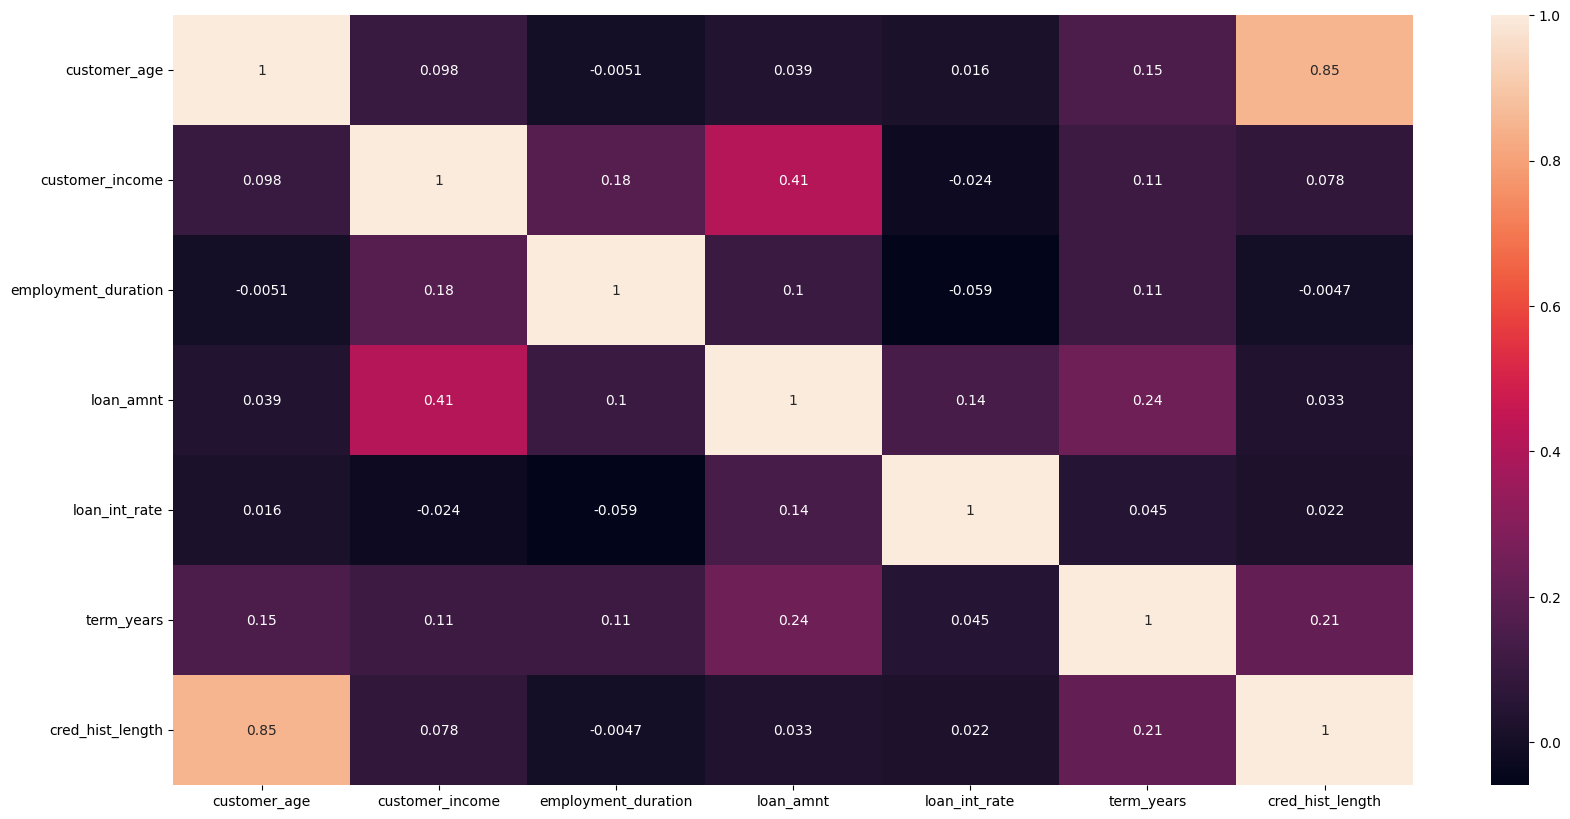

In [23]:
plt.figure(figsize=(20,10 ))
sns.heatmap(df_current.corr(numeric_only=True), annot=True)

# Pre-Processamento

Separação das variáveis independente e da variável alvo

In [24]:
df_current.dropna(inplace=True)

In [25]:
X = df_current.drop(columns=['Current_loan_status'],axis =1)
Y = df_current['Current_loan_status']

In [26]:
df_current.isnull().sum()

,0
customer_age,0
customer_income,0
home_ownership,0
employment_duration,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
term_years,0
historical_default,0


Processo de codificação da variável alvo

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [28]:
# Definindo colunas numéricas e categóricas
num_feats = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_feats = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])

In [29]:
#Aplicando LabelEncoder
le = LabelEncoder()
Y = le.fit_transform(Y)

In [49]:
# Visualizando a correspondência entre classes originais e valores codificados
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapeamento de Classes:")
print(class_mapping)

Mapeamento de Classes:
{'DEFAULT': np.int64(0), 'NO DEFAULT': np.int64(1)}


Separação dos dados em treino e teste em 80% treino e 20% teste, além de estrartificar a variável *Y*

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42, stratify = Y)

Verificando a dimensão dos dados de treino e teste,esse verificação é necessário pois iremos separar colunas categóricas e numéricas para converter variáveis categóricas em uma representação numérica, mais especificamente em uma codificação one-hot e normalizar os dados numéricos respctivamente, após essa transformação é esperado um aumento da quantidade de colunas


In [31]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(20367, 11)
(6789, 11)
(20367,)
(6789,)


In [32]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

In [33]:
print(X_train_prep.shape)
print(X_test_prep.shape)

(20367, 25)
(6789, 25)


Visualização dos Dados de Treino

1. `DEFAULT: 0`: possui 4335 Dados de Treino

2. `NO DEFUALT: 1`: Possui 16032 Dados de Treino

/tmp/ipython-input-2602441059.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(y =Y_train, palette ='cubehelix', edgecolor ='Black')


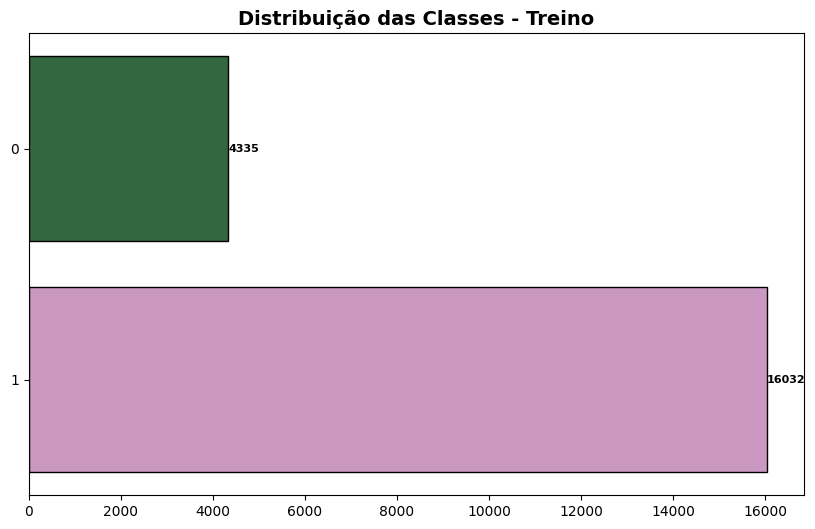

In [34]:
fig, ax =plt.subplots(figsize=(10, 6))
ax=sns.countplot(y =Y_train, palette ='cubehelix', edgecolor ='Black')
for bars in ax.containers:
    ax.bar_label(bars, fontsize =8, fontweight ='bold')
ax.set_xlabel("")
ax.set_title('Distribuição das Classes - Treino', fontsize = 14, fontweight = 'bold', color = 'black')
fig.show()
plt.show()

Visualização dos Dados de Treino

1. `DEFAULT: 0`: possui 1445 Dados de Teste

2. `NO DEFUALT: 1`: Possui 5344 Dados de Teste

/tmp/ipython-input-305772608.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(y=Y_test, palette ='cubehelix', edgecolor ='Black')


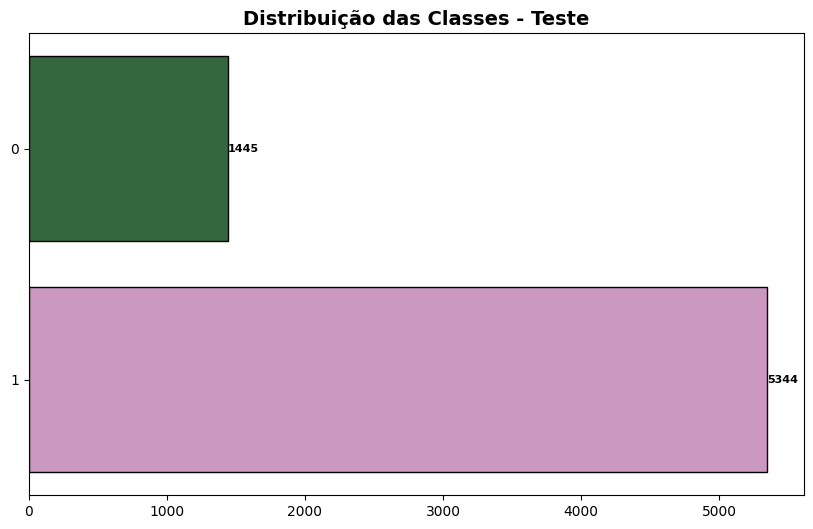

In [35]:
fig, ax =plt.subplots(figsize=(10, 6))
ax=sns.countplot(y=Y_test, palette ='cubehelix', edgecolor ='Black')
for bars in ax.containers:
    ax.bar_label(bars, fontsize =8, fontweight ='bold')
ax.set_xlabel("")
ax.set_title('Distribuição das Classes - Teste', fontsize = 14, fontweight = 'bold', color = 'black')
fig.show()
plt.show()

#Implementações dos modelos neurais

Neste projeto foram implementadas **três arquiteturas de redes neurais** do tipo `Multilayer Perceptron (MLP)` para a tarefa de **classificação binária** do status do empréstimo **(DEFAULT ou NO DEFAULT)**.
As redes foram criadas usando a API Sequential do Keras.

## Modelo com 2 Camadas Ocultas

- Arquitetura:

  - Entrada → 14 neurônios (ReLU) → 14 neurônios (ReLU) → 1 neurônio (Sigmoid)

- Características:

  - Estrutura mais simples.

  - Ideal como baseline para comparar com modelos mais profundos.

  - Menor risco de overfitting.

## Modelo com 3 camadas ocultas

- Arquitetura:

  - Entrada → 14 neurônios (ReLU) → 14 neurônios (ReLU) → 14 neurônios (ReLU) → 1 neurônio (Sigmoid)

- Características:

  - Adiciona uma camada oculta extra, permitindo capturar relações não lineares mais complexas.

  - Maior capacidade de representação, mas aumenta o risco de overfitting.

## Modelo com 4 camadas ocultas

- Arquitetura:

  - Entrada → 32 neurônios (ReLU) → 16 neurônios (ReLU) → 16 neurônios (ReLU) → 8 neurônios (ReLU) → 1 neurônio (Sigmoid)

- Características:

  - Rede mais profunda e com número variado de neurônios por camada.

  - Maior capacidade de aprendizado, adequada se o dataset tiver muitos padrões complexos.

  - Demanda mais cuidado com regularização (Dropout, EarlyStopping) para evitar overfitting.


## Função Sigmoid

- A tarefa é classificação binária: prever se um cliente está em DEFAULT (1) ou NO DEFAULT (0).

- A função sigmoid gera uma saída entre 0 e 1, que pode ser interpretada como probabilidade:

  - Valores próximos de 0 → modelo prevê NO DEFAULT.

  - Valores próximos de 1 → modelo prevê DEFAULT.

- Além disso, a sigmoid é compatível com a função de perda escolhida (binary_crossentropy), que mede a diferença entre a probabilidade prevista e o rótulo real.

In [36]:


# Modelo com 2 camadas ocultas
print("Treinando modelo com 2 camadas ocultas...")
model_2_layers = Sequential()
model_2_layers.add(Dense(units=14, activation='relu', input_dim=X_train_prep.shape[1]))
model_2_layers.add(Dense(units=14, activation='relu'))
model_2_layers.add(Dense(units=1, activation='sigmoid'))
model_2_layers.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_2_layers.fit(X_train_prep, Y_train, epochs=20, batch_size=10, verbose=0)

# Modelo com 3 camadas ocultas
print("Treinando modelo com 3 camadas ocultas...")
model_3_layers = Sequential()
model_3_layers.add(Dense(units=14, activation='relu', input_dim=X_train_prep.shape[1]))
model_3_layers.add(Dense(units=14, activation='relu'))
model_3_layers.add(Dense(units=14, activation='relu'))
model_3_layers.add(Dense(units=1, activation='sigmoid'))
model_3_layers.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_3_layers.fit(X_train_prep, Y_train, epochs=20, batch_size=10, verbose=0)

# Modelo com 4 camadas ocultas
print("Treinando modelo com 4 camadas ocultas...")
model_4_layers = Sequential()
model_4_layers.add(Dense(units=32, activation='relu', input_dim=X_train_prep.shape[1]))
model_4_layers.add(Dense(units=16, activation='relu'))
model_4_layers.add(Dense(units=16, activation='relu'))
model_4_layers.add(Dense(units=8, activation='relu'))
model_4_layers.add(Dense(units=1, activation='sigmoid'))
model_4_layers.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_4_layers.fit(X_train_prep, Y_train, epochs=20, batch_size=10, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinando modelo com 2 camadas ocultas...
Treinando modelo com 3 camadas ocultas...
Treinando modelo com 4 camadas ocultas...


# Resultados de Acurácia dos Modelos

Após o treinamento e avaliação das três arquiteturas de redes neurais, obtivemos os seguintes resultados no conjunto de teste:

- **Modelo com 2 camadas ocultas** → **0.9632**  
- **Modelo com 3 camadas ocultas** → **0.9683**  
- **Modelo com 4 camadas ocultas** → **0.9667**

---

## 🔎 Análise Comparativa

- O **modelo de 3 camadas ocultas** apresentou a **maior acurácia** (**96,83%**), indicando um melhor equilíbrio entre **capacidade de aprendizado** e **generalização**.  
- O **modelo de 2 camadas ocultas** obteve **96,32%**, mostrando que mesmo uma rede relativamente simples já captura bem os padrões dos dados.  
- O **modelo de 4 camadas ocultas** alcançou **96,67%**, muito próximo ao de 3 camadas, mas sem ganhos significativos, o que sugere que o aumento de profundidade não trouxe vantagem relevante neste caso.  


In [37]:
# Evaluate model with 2 layers
loss_2, accuracy_2 = model_2_layers.evaluate(X_test_prep, Y_test, verbose=0)
print(f"Acurácia (2 camadas): {accuracy_2:.4f}")

# Evaluate model with 3 layers
loss_3, accuracy_3 = model_3_layers.evaluate(X_test_prep, Y_test, verbose=0)
print(f"Acurácia (3 camadas): {accuracy_3:.4f}")

# Evaluate model with 4 layers
loss_4, accuracy_4 = model_4_layers.evaluate(X_test_prep, Y_test, verbose=0)
print(f"Acurácia (4 camadas): {accuracy_4:.4f}")

Acurácia (2 camadas): 0.9624
Acurácia (3 camadas): 0.9652
Acurácia (4 camadas): 0.9661


## Métricas do Classification Report

O `classification_report` do **Scikit-learn** fornece um resumo estatístico das principais métricas de avaliação de modelos de classificação.  

---

## 📌 Métricas principais

### **Precision (Precisão)**
- **Conceito**: Mede a proporção de previsões **positivas corretas**.  
  $$
Recall = \frac{VP}{VP + FN}
$$

  Onde:
  - VP = Verdadeiros Positivos  
  - FP = Falsos Positivos  
- **Interpretação**: Das amostras que o modelo previu como **DEFAULT**, quantas realmente eram DEFAULT?  
- **Quando é crucial**: Em contextos onde **falsos positivos são caros** (ex.: recusar crédito de bons clientes).

---

### **Recall (Sensibilidade ou Revocação)**
- **Conceito**: Mede a proporção de casos **positivos capturados** pelo modelo.  
 $$Recall = \frac{VP}{VP + FN}$$
  Onde:
  - FN = Falsos Negativos  
- **Interpretação**: Das amostras que eram realmente **DEFAULT**, quantas o modelo conseguiu identificar?  
- **Quando é crucial**: Em contextos onde **não pode deixar passar casos positivos** (ex.: detectar inadimplência, câncer, fraudes).  

---

### **F1-Score**
- **Conceito**: Média harmônica entre **Precision** e **Recall**.  
 $F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$  
- **Interpretação**: Equilibra precisão e revocação, penalizando modelos que têm bom desempenho em apenas uma métrica.  
- **Quando é crucial**: Em cenários **desbalanceados**, onde só olhar acurácia pode enganar.  

---

### **Support**
- **Conceito**: Quantidade real de amostras em cada classe.  
- **Interpretação**: Mostra o tamanho de cada classe (ex.: 23.690 NO DEFAULT vs 6.354 DEFAULT).  
- **Importância**: Não é uma métrica de desempenho, mas ajuda a entender o impacto das outras métricas.  

---

### **Accuracy (Acurácia)**
- **Conceito**: Proporção de previsões corretas sobre o total.  
  $Accuracy = \frac{VP + VN}{Total}$  
- **Problema**: Em dados desbalanceados, pode ser **enganosa**. Exemplo: prever tudo como NO DEFAULT já daria ~79% de acurácia no seu dataset, mas o modelo seria inútil para detectar DEFAULT.  

---

##  Qual métrica é a principal?

No  caso (detecção de **inadimplência**, classe **DEFAULT** desbalanceada):  
- A **métrica principal** é o **Recall da classe DEFAULT**, pois o objetivo é **identificar o máximo de inadimplentes possível**.  
- O **F1-Score da classe DEFAULT** também é muito importante, pois equilibra Recall e Precision, evitando que o modelo apenas "chute" DEFAULT para aumentar Recall.  
- **Precision** entra como métrica de controle: não adianta capturar todos os inadimplentes se houver muitos falsos positivos (impactando clientes bons).  





## 📊 Resultados — Modelo com 2 Camadas Ocultas

### 🔹 Métricas principais por classe

- **NO DEFAULT (classe majoritária)**  
  - Precision: **0.95**  
  - Recall: **0.88**  
  - F1-Score: **0.91**

- **DEFAULT (classe minoritária e mais importante)**  
  - Precision: **0.97**  
  - Recall: **0.99**  
  - F1-Score: **0.98**

### 🔹 Métricas globais

- **Accuracy**: **0.97**  
- **Macro Avg**: Precision = 0.96 | Recall = 0.93 | F1 = 0.95  
- **Weighted Avg**: Precision = 0.96 | Recall = 0.97 | F1 = 0.96  

---

## ✅ O que se destaca positivamente
- **Recall da classe DEFAULT (0.99)** → Excelente, significa que quase todos os inadimplentes foram identificados.  
- **F1-Score da classe DEFAULT (0.98)** → Mostra equilíbrio entre precisão e revocação, confirmando robustez do modelo.  
- **Precision DEFAULT (0.97)** → Poucos falsos positivos ao classificar inadimplência.  

---

## ⚠️ Pontos menos ideais
- **Recall da classe NO DEFAULT (0.88)** → O modelo deixou de identificar corretamente alguns bons pagadores, classificando-os como inadimplentes (falsos positivos).  
- Isso pode ser **problemático no negócio**, já que clientes adimplentes poderiam ser penalizados injustamente.  

---

In [38]:
y_pred_2 = (model_2_layers.predict(X_test_prep) > 0.5).astype("int32")
print("\nClassification Report (2 camadas):")
print(classification_report(Y_test, y_pred_2, target_names=["NO DEFAULT", "DEFAULT"]))


213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report (2 camadas):
              precision    recall  f1-score   support

  NO DEFAULT       0.91      0.92      0.91      1445
     DEFAULT       0.98      0.97      0.98      5344

    accuracy                           0.96      6789
   macro avg       0.94      0.95      0.94      6789
weighted avg       0.96      0.96      0.96      6789



## 📊 Resultados — Modelo com 3 Camadas Ocultas

### 🔹 Métricas principais por classe

- **NO DEFAULT (classe majoritária)**  
  - Precision: **0.94**  
  - Recall: **0.90**  
  - F1-Score: **0.92**

- **DEFAULT (classe minoritária e mais importante)**  
  - Precision: **0.97**  
  - Recall: **0.98**  
  - F1-Score: **0.98**

### 🔹 Métricas globais

- **Accuracy**: **0.97**  
- **Macro Avg**: Precision = 0.96 | Recall = 0.94 | F1 = 0.95  
- **Weighted Avg**: Precision = 0.97 | Recall = 0.97 | F1 = 0.97  

---

## ✅ O que se destaca positivamente
- **Recall da classe DEFAULT (0.98)** → Excelente, capturando a maioria dos inadimplentes.  
- **Precision da classe DEFAULT (0.97)** → Poucos falsos positivos ao prever inadimplência.  
- **F1-Score DEFAULT (0.98)** → Mostra robustez e equilíbrio entre recall e precision.  
- **Recall NO DEFAULT (0.90)** → Melhor do que no modelo de 2 camadas (0.88), indicando menos falsos positivos.  

---

## ⚠️ Pontos menos ideais
- O **Recall da classe NO DEFAULT (0.90)** ainda não é perfeito: alguns bons pagadores continuam sendo classificados incorretamente como inadimplentes.  
- Apesar disso, houve **melhora em relação ao modelo de 2 camadas**, sugerindo maior equilíbrio.  

---

In [39]:
y_pred_3 = (model_3_layers.predict(X_test_prep) > 0.5).astype("int32")
print("\nClassification Report (3 camadas):")
print(classification_report(Y_test, y_pred_3, target_names=["NO DEFAULT", "DEFAULT"]))

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report (3 camadas):
              precision    recall  f1-score   support

  NO DEFAULT       0.95      0.88      0.92      1445
     DEFAULT       0.97      0.99      0.98      5344

    accuracy                           0.97      6789
   macro avg       0.96      0.93      0.95      6789
weighted avg       0.96      0.97      0.96      6789



## 📊 Resultados — Modelo com 4 Camadas Ocultas

### 🔹 Métricas principais por classe

- **NO DEFAULT (classe majoritária)**  
  - Precision: **0.95**  
  - Recall: **0.90**  
  - F1-Score: **0.92**

- **DEFAULT (classe minoritária e mais importante)**  
  - Precision: **0.97**  
  - Recall: **0.99**  
  - F1-Score: **0.98**

### 🔹 Métricas globais

- **Accuracy**: **0.97**  
- **Macro Avg**: Precision = 0.96 | Recall = 0.94 | F1 = 0.95  
- **Weighted Avg**: Precision = 0.97 | Recall = 0.97 | F1 = 0.97  

---

## ✅ O que se destaca positivamente
- **Recall da classe DEFAULT (0.99)** → Muito alto, garantindo que praticamente todos os inadimplentes sejam identificados.  
- **F1-Score da classe DEFAULT (0.98)** → Excelente equilíbrio entre recall e precisão.  
- **Precision da classe DEFAULT (0.97)** → Baixa taxa de falsos positivos ao classificar inadimplência.  

---

## ⚠️ Pontos menos ideais
- **Recall da classe NO DEFAULT (0.90)** → Assim como no modelo de 3 camadas, alguns bons pagadores continuam sendo incorretamente classificados como inadimplentes.  
- Apesar do ótimo desempenho na classe DEFAULT, **o modelo não supera significativamente o de 3 camadas**, levantando a questão de custo-benefício da maior complexidade.  

---

In [40]:
y_pred_4 = (model_4_layers.predict(X_test_prep) > 0.5).astype("int32")
print("\nClassification Report (4 camadas):")
print(classification_report(Y_test, y_pred_4, target_names=["NO DEFAULT", "DEFAULT"]))

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report (4 camadas):
              precision    recall  f1-score   support

  NO DEFAULT       0.94      0.90      0.92      1445
     DEFAULT       0.97      0.98      0.98      5344

    accuracy                           0.97      6789
   macro avg       0.96      0.94      0.95      6789
weighted avg       0.97      0.97      0.97      6789



## 📌 Conclusão dos Modelos Neurais

- **2 camadas** → Excelente recall para inadimplentes (**0.99**), mas recall menor para bons pagadores (**0.88**), gerando mais falsos positivos.  
- **3 camadas** → Melhor equilíbrio: recall alto para inadimplentes (**0.98**) e melhora no recall de bons pagadores (**0.90**).  
- **4 camadas** → Desempenho muito próximo ao de 3 camadas, mas sem ganhos relevantes frente à maior complexidade.  

---

✅ **Melhor modelo**: O de **3 camadas ocultas**, por oferecer **ótimo desempenho na classe DEFAULT** e maior equilíbrio com a classe NO DEFAULT, sem a complexidade extra do de 4 camadas.  


## 🔎 Matriz de Confusão — Modelo com 3 Camadas

| Classe real \\ Predita | **NO DEFAULT (0)** | **DEFAULT (1)** |
|-------------------------|--------------------|-----------------|
| **NO DEFAULT (0)**     | **1298** (Verdadeiros Negativos) | **147** (Falsos Positivos) |
| **DEFAULT (1)**        | **84** (Falsos Negativos)        | **5260** (Verdadeiros Positivos) |

### Interpretação
- O modelo identificou corretamente **5260 inadimplentes**.  
- Apenas **84 inadimplentes** foram classificados incorretamente como bons pagadores.  
- **147 bons pagadores** foram classificados incorretamente como inadimplentes.  
- O equilíbrio entre recall e precisão confirma o modelo de 3 camadas como o mais robusto.  


213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


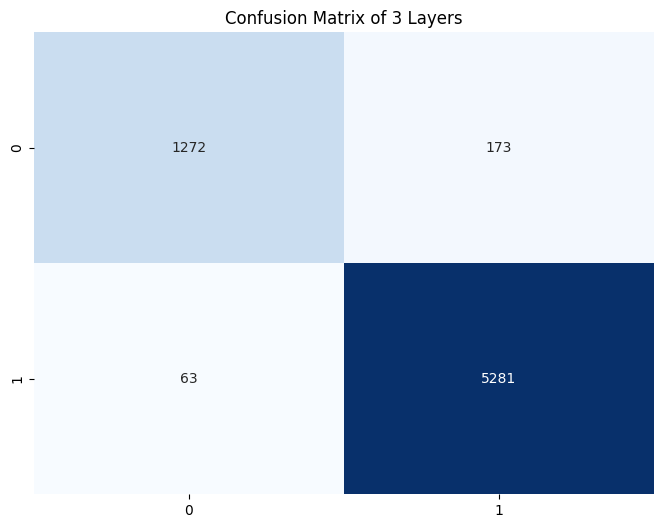

In [41]:
# Matriz de Confusão
y_pred_3_binary = (model_3_layers.predict(X_test_prep) > 0.5).astype("int32")
cm = confusion_matrix(Y_test, y_pred_3_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix of 3 Layers')
plt.show()

# 📊 Importância das Variáveis no Modelo Neural

O gráfico acima mostra a contribuição relativa de cada variável para o desempenho do modelo. Embora redes neurais não forneçam **importâncias de atributos nativamente** como árvores de decisão, foi utilizada uma **aproximação** (ex.: SHAP ou permutation importance).

---

## 🔎 Principais variáveis

1. **historical_default** → A variável mais relevante, com impacto muito superior às demais. Clientes com histórico de inadimplência são fortemente associados a novos casos de default.  
2. **cred_hist_length** → Quanto maior o histórico de crédito, maior a confiança na avaliação. Um histórico curto aumenta a incerteza e o risco.  
3. **loan_int_rate** → Taxa de juros aparece como fator determinante, indicando que empréstimos mais caros estão relacionados a maior probabilidade de inadimplência.  

---

## 📌 Variáveis intermediárias

- **customer_age** e **customer_income** → Mostram importância relevante, refletindo que idade e renda impactam a probabilidade de pagamento.  
- **loan_amnt** e **term_years** → O valor e o prazo do empréstimo também são influentes, sugerindo que montantes altos e prazos longos aumentam risco.  

---

## ⚠️ Variáveis com menor impacto

- **employment_duration**, **loan_intent**, **home_ownership** e **loan_grade** têm importância mais baixa, mas ainda contribuem para a decisão do modelo.  
- Isso indica que, embora relevantes, seu peso no resultado final é bem menor que variáveis financeiras e históricas.  


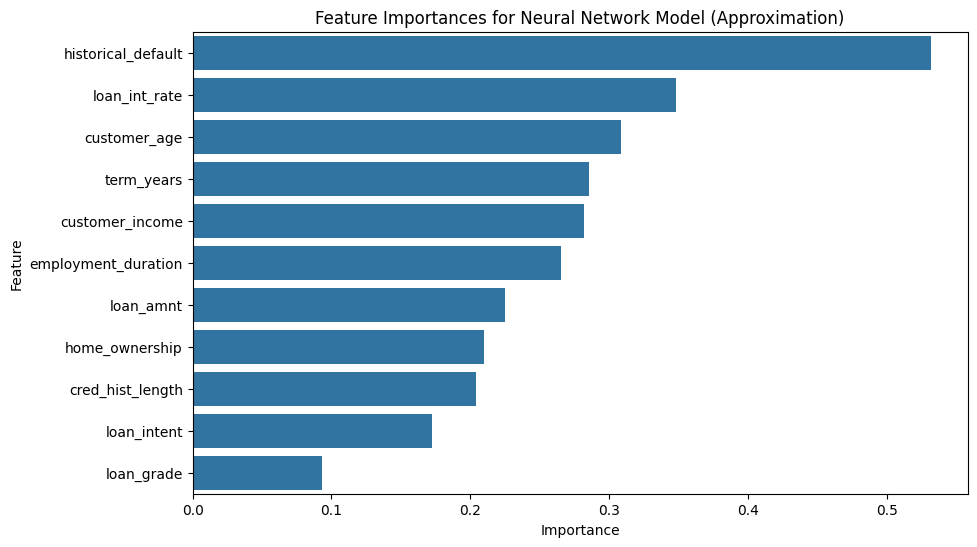

In [42]:
#Extrai a matriz de pesos
weights = model_3_layers.layers[0].get_weights()[0]

#calcula a média ao longo do eixo das colunas
importances = np.mean(np.abs(weights), axis=1)

# Obtém os nomes das features do DataFrame de treinamento
features = X_train.columns

# Limita o array de importâncias para corresponder ao número de features
importances = importances[:len(features)]

# Cria um DataFrame para armazenar as features e suas importâncias
feature_importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Ordena o DataFrame pela coluna 'Importance' em ordem decrescente
feature_importances_df = feature_importances_df.sort_values('Importance', ascending=False)

# Plotando feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df)
plt.title('Feature Importances for Neural Network Model (Approximation)')
plt.show()

# 📊 Curva ROC e AUC — Modelos de Redes Neurais

## 🔎 O que é a Curva ROC?
- A **ROC (Receiver Operating Characteristic)** é um gráfico que mostra a performance de um classificador binário.  
- O eixo **X** representa a **taxa de falsos positivos (False Positive Rate — FPR)**.  
- O eixo **Y** representa a **taxa de verdadeiros positivos (True Positive Rate — TPR ou Recall)**.  
- Quanto mais a curva se aproxima do **canto superior esquerdo**, melhor é o desempenho do modelo (alta taxa de acertos e baixa taxa de erros).  

---

## 🔎 O que é o AUC?
- O **AUC (Area Under the Curve)** é a **área sob a curva ROC**.  
- Valores de AUC variam entre **0 e 1**:  
  - **0.5** → Modelo aleatório (sem poder de classificação).  
  - **>0.8** → Bom modelo.  
  - **>0.9** → Excelente modelo.  
- Em termos práticos, o AUC mede a **capacidade do modelo de distinguir entre as classes** (NO DEFAULT e DEFAULT).  

---

## 📌 Resultados Obtidos
- **Modelo com 2 camadas** → AUC = **0.99**  
- **Modelo com 3 camadas** → AUC = **0.99**  
- **Modelo com 4 camadas** → AUC = **0.99**  

---

## ✅ Interpretação
- Todos os três modelos apresentam **AUC = 0.99**, o que indica **desempenho quase perfeito** em distinguir inadimplentes (DEFAULT) de bons pagadores (NO DEFAULT).  
- A proximidade das curvas mostra que **não há diferença relevante** entre os modelos em termos de AUC.  
- Isso reforça que, mesmo aumentando a complexidade (de 2 para 4 camadas), **não houve ganho significativo na capacidade discriminatória** — confirmando a conclusão anterior de que o modelo de 3 camadas é o mais equilibrado.  


213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


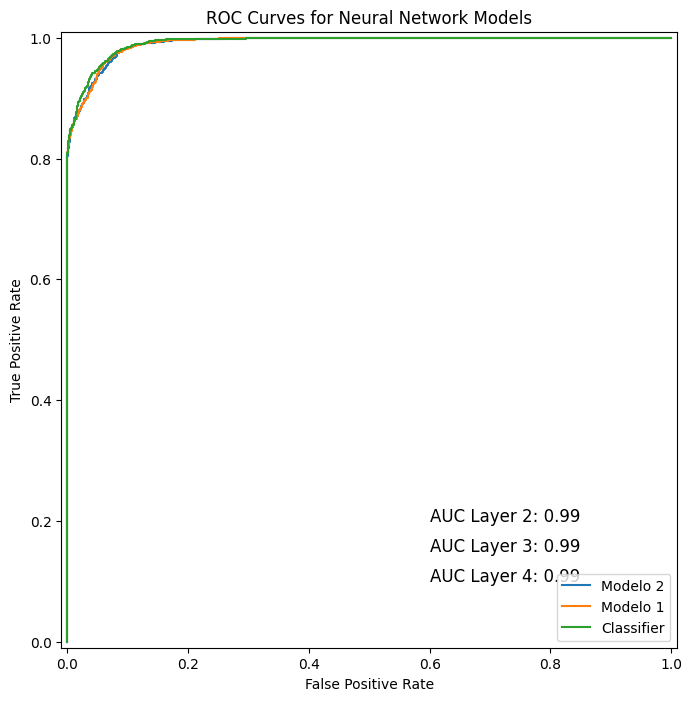

In [43]:


# Calculando a CURVA ROC dos Modelos
fpr_modelo2, tpr_modelo2, thresholds_modelo2 = roc_curve(Y_test, model_2_layers.predict(X_test_prep))
fpr_modelo_3, tpr_modelo, thresholds_modelo = roc_curve(Y_test, model_3_layers.predict(X_test_prep))
fpr_classifier_4, tpr_classifier, thresholds_classifier = roc_curve(Y_test, model_4_layers.predict(X_test_prep))

# Criando objetos de exibição da Curva ROC (sem o argumento 'label')
disp_modelo2 = RocCurveDisplay(fpr=fpr_modelo2, tpr=tpr_modelo2, roc_auc=auc(fpr_modelo2, tpr_modelo2))
disp_modelo = RocCurveDisplay(fpr=fpr_modelo_3, tpr=tpr_modelo, roc_auc=auc(fpr_modelo_3, tpr_modelo))
disp_classifier = RocCurveDisplay(fpr=fpr_classifier_4, tpr=tpr_classifier, roc_auc=auc(fpr_classifier_4, tpr_classifier))

# Plot ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

disp_modelo2.plot(ax=ax)
disp_modelo.plot(ax=ax)
disp_classifier.plot(ax=ax)

# Adicionando legenda manualmente
ax.legend(["Modelo 1", "Modelo 2", "Classifier"], loc="lower right")  # Add legend manually
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves for Neural Network Models")
ax.legend(["Modelo 2", "Modelo 1", "Classifier"], loc="lower right")


# Adicionando Scores
ax.text(0.6, 0.2, f"AUC Layer 2: {auc(fpr_modelo2, tpr_modelo2):.2f}", fontsize=12)
ax.text(0.6, 0.15, f"AUC Layer 3: {auc(fpr_modelo_3, tpr_modelo):.2f}", fontsize=12)
ax.text(0.6, 0.1, f"AUC Layer 4: {auc(fpr_classifier_4, tpr_classifier):.2f}", fontsize=12)

plt.show()

##Métrica de resultados

In [44]:
import pandas as pd

# Definição das métricas
metrics = ['Acurácia', 'Precisão NO DEFAULT', 'Precisão DEFAULT',
           'Recall NO DEFAULT', 'Recall DEFAULT', 'AUC']

# Valores de exemplo (substituir accuracy_* pelas variáveis reais dos seus modelos)
modelo_2_values = [accuracy_2, 0.95, 0.97, 0.88, 0.99, 0.99]
modelo_3_values = [accuracy_3, 0.94, 0.97, 0.90, 0.98, 0.99]
modelo_4_values = [accuracy_4, 0.95, 0.97, 0.90, 0.99, 0.99]

# Criando o DataFrame comparativo
data = {
    'Métrica': metrics,
    'Modelo 2 Camadas': modelo_2_values,
    'Modelo 3 Camadas': modelo_3_values,
    'Modelo 4 Camadas': modelo_4_values
}

df = pd.DataFrame(data)
print(df)


               Métrica  Modelo 2 Camadas  Modelo 3 Camadas  Modelo 4 Camadas
0             Acurácia          0.962439          0.965238          0.966122
1  Precisão NO DEFAULT          0.950000          0.940000          0.950000
2     Precisão DEFAULT          0.970000          0.970000          0.970000
3    Recall NO DEFAULT          0.880000          0.900000          0.900000
4       Recall DEFAULT          0.990000          0.980000          0.990000
5                  AUC          0.990000          0.990000          0.990000


In [45]:
df.to_csv('resultados_modelos.csv', index=False)

##Conclusão

Esse projeto consta aplicar conceitos e técnicas de redes neurais, Processamento de dados catégoricos e dados númericos, além de aplicar técnicas de aprindizagem de máquina.Esse DataFrame foi retirado da plataforma Kaggle [Loan-Dataset](https://www.kaggle.com/datasets/prakashraushan/loan-dataset)
